![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

## Create a HydroDataFrame

We want to create one data frame containing streamflow, meteological information, and SNOTEL for our period of record

In [10]:
from pynhd import NLDI
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [11]:
station_id = "10109000"
basinname = "LoganRiver"

## Load data

We need to load the saved data into our script to process and combine.

We will start with the SNOTEL data

In [12]:
#load snotel data
unprocessed_SNOTEL = {}
#read all files in the following path into the dictionary
path = 'files/SNOTEL'
for filename in os.listdir(path):
    if filename.endswith('.csv'):
        #select the name of the file between the _ and _
        name = filename.split('_')[1] 
        unprocessed_SNOTEL[name] = pd.read_csv(os.path.join(path, filename))
        #make the date a datetime object and set to the index
        unprocessed_SNOTEL[name]['Date'] = pd.to_datetime(unprocessed_SNOTEL[name]['Date'])
        unprocessed_SNOTEL[name].set_index('Date', inplace=True)
        #rename the Snow Water Equivalent (m) Start of Day Values to SWE_cm
        unprocessed_SNOTEL[name].rename(columns={'Snow Water Equivalent (m) Start of Day Values': f"{name}_SWE_cm"}, inplace=True)
        #convert SWE_m to cm
        unprocessed_SNOTEL[name][f"{name}_SWE_cm"] = unprocessed_SNOTEL[name][f"{name}_SWE_cm"] * 100
        #remove the Water_Year column
        unprocessed_SNOTEL[name].drop(columns=['Water_Year'], inplace=True)
        #we need to know how many obs for each DF, print the df name, its length, and the start/end dates
        print(f"{name}: {len(unprocessed_SNOTEL[name])} start date: {unprocessed_SNOTEL[name].index.min()} end date: {unprocessed_SNOTEL[name].index.max()}")
    



1013: 155 start date: 2025-10-01 00:00:00 end date: 2026-03-04 00:00:00
1013: 155 start date: 2025-10-01 00:00:00 end date: 2026-03-04 00:00:00
1113: 155 start date: 2025-10-01 00:00:00 end date: 2026-03-04 00:00:00
1113: 155 start date: 2025-10-01 00:00:00 end date: 2026-03-04 00:00:00
1115: 155 start date: 2025-10-01 00:00:00 end date: 2026-03-04 00:00:00
1115: 155 start date: 2025-10-01 00:00:00 end date: 2026-03-04 00:00:00
823: 155 start date: 2025-10-01 00:00:00 end date: 2026-03-04 00:00:00
823: 155 start date: 2025-10-01 00:00:00 end date: 2026-03-04 00:00:00
DAN: 6195 start date: 2004-10-01 00:00:00 end date: 2021-09-16 00:00:00
SLI: 6257 start date: 2004-10-01 00:00:00 end date: 2021-11-17 00:00:00
TES: 629 start date: 2005-03-01 00:00:00 end date: 2006-11-19 00:00:00
TUM: 6257 start date: 2004-10-01 00:00:00 end date: 2021-11-17 00:00:00


In [13]:
#The TES site is missing many values and will not be useful for our analysis, remove it
unprocessed_SNOTEL.pop('TES', None)

#The site with the latest start date will guide the rest
latest_start_date = max([df.index.min() for df in unprocessed_SNOTEL.values()])

#The site with the earliest end date will guide the rest
soonest_end_date = min([df.index.max() for df in unprocessed_SNOTEL.values()])
for key in unprocessed_SNOTEL.keys():
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index >= latest_start_date]
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index <= soonest_end_date]

#merge all dictionary dataframes into one larger dataframe
SNOTEL_df = pd.concat(unprocessed_SNOTEL.values(), axis=1)
#set the date index to be the index of the first dataframe in the dictionary

SNOTEL_df.head()

,1013_SWE_cm,1113_SWE_cm,1115_SWE_cm,823_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,TUM_SWE_cm
Date,,,,,,,


## Load the meteorologogical data from Daymet and NLDAS

In [14]:
#Read the data from PyDayMet 
PyDayMet_df = pd.read_csv(f"files/PyDayMet/PyDayMet_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
PyDayMet_df['Date'] = pd.to_datetime(PyDayMet_df['Date'])
PyDayMet_df.set_index('Date', inplace=True)
PyDayMet_df.head()

,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,vp_Pa,tmean
Date,,,,,,,,
1980-01-01,33914.08,0.0,356.43,2.943,6.07,-12.54,232.94,-3.235
1980-01-02,33952.03,0.0,363.52,2.943,7.82,-11.91,239.32,-2.045
1980-01-03,33993.09,0.0,364.49,2.943,7.14,-12.50,229.62,-2.680
1980-01-04,34037.22,0.0,340.58,2.943,5.89,-10.41,276.75,-2.260
1980-01-05,34084.41,0.0,318.39,2.943,6.51,-7.77,340.48,-0.630


In [15]:
#Read the data from NLDAS 
NLDAS_df = pd.read_csv(f"files/NLDAS/NLDAS_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
NLDAS_df['Date'] = pd.to_datetime(NLDAS_df['Date'])
NLDAS_df.set_index('Date', inplace=True)
NLDAS_df.head()

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2006-01-01,0.085486,269.364046,5.888540,0.056244,77090.495361,86.825139,0.003591,-1.136388,0.765995,4.314145,1.026540
2006-01-02,0.000000,259.221946,0.688696,0.034813,77359.795686,58.862592,0.003161,-2.723593,0.473683,-3.055378,2.621259
2006-01-03,0.088004,275.126700,8.144629,0.045749,77458.371991,76.688075,0.003959,-0.231871,1.475428,2.806314,2.393495
2006-01-04,0.000000,238.787673,0.012821,0.024564,78813.099391,85.408831,0.003004,-3.696805,0.063898,2.563156,0.293499
2006-01-05,0.000000,194.823247,0.000000,0.016176,79739.495833,97.998549,0.002277,-6.470342,0.015885,0.223267,0.186848


## Load the streamflow data

In [16]:
streamflow_df = pd.read_csv(f"files/NWIS/streamflow_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
streamflow_df['Date'] = pd.to_datetime(streamflow_df['Date'])
streamflow_df.set_index('Date', inplace=True)

streamflow_df.head()

,site_no,flow_cms
Date,,
1980-01-01,10109000,2.718413
1980-01-02,10109000,2.718413
1980-01-03,10109000,2.718413
1980-01-04,10109000,2.661779
1980-01-05,10109000,2.718413


In [17]:
# FIX timezone issue FIRST
SNOTEL_df.index = pd.to_datetime(SNOTEL_df.index).tz_localize(None)
PyDayMet_df.index = pd.to_datetime(PyDayMet_df.index).tz_localize(None)
NLDAS_df.index = pd.to_datetime(NLDAS_df.index).tz_localize(None)
streamflow_df.index = pd.to_datetime(streamflow_df.index).tz_localize(None)

# merge without clipping
Hydro_df = pd.concat([SNOTEL_df, PyDayMet_df, NLDAS_df, streamflow_df], axis=1)

# fill missing values
Hydro_df = Hydro_df.fillna(0)

Hydro_df.head()

,1013_SWE_cm,1113_SWE_cm,1115_SWE_cm,823_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,TUM_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,...,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,site_no,flow_cms
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33914.08,0.0,356.43,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.718413
1980-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33952.03,0.0,363.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.718413
1980-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33993.09,0.0,364.49,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.718413
1980-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34037.22,0.0,340.58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.661779
1980-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34084.41,0.0,318.39,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.718413


## Load our catchment information

In [18]:
# basin_info = pd.read_csv(f"files/basin_info/basin_info_{station_id}.csv")
# basin_info.head()

## Now we can merge into one dataframe

In [19]:
# FIX timezone
SNOTEL_df.index = pd.to_datetime(SNOTEL_df.index).tz_localize(None)
PyDayMet_df.index = pd.to_datetime(PyDayMet_df.index).tz_localize(None)
NLDAS_df.index = pd.to_datetime(NLDAS_df.index).tz_localize(None)
streamflow_df.index = pd.to_datetime(streamflow_df.index).tz_localize(None)

# ONLY keep good SNOTEL stations (drop the new broken ones)
SNOTEL_df = SNOTEL_df[["TUM_SWE_cm", "DAN_SWE_cm", "SLI_SWE_cm"]]

# merge everything
Hydro_df = pd.concat([SNOTEL_df, PyDayMet_df, NLDAS_df, streamflow_df], axis=1)

# fill missing
Hydro_df = Hydro_df.fillna(0)

Hydro_df.head()

,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,vp_Pa,...,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,site_no,flow_cms
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-01,0.0,0.0,0.0,33914.08,0.0,356.43,2.943,6.07,-12.54,232.94,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.718413
1980-01-02,0.0,0.0,0.0,33952.03,0.0,363.52,2.943,7.82,-11.91,239.32,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.718413
1980-01-03,0.0,0.0,0.0,33993.09,0.0,364.49,2.943,7.14,-12.50,229.62,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.718413
1980-01-04,0.0,0.0,0.0,34037.22,0.0,340.58,2.943,5.89,-10.41,276.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.661779
1980-01-05,0.0,0.0,0.0,34084.41,0.0,318.39,2.943,6.51,-7.77,340.48,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10109000,2.718413


In [20]:
df = Hydro_df.copy()
df = df[(df.index >= "2018-10-01") & (df.index <= "2019-09-30")]
df.head()

,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,vp_Pa,...,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,site_no,flow_cms
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-01,0.0,0.0,0.0,41618.54,10.23,254.74,0.0,16.31,4.64,348.27,...,0.203608,78321.499632,135.886637,0.003442,11.841767,0.000000,0.633532,0.026502,10109000,2.353126
2018-10-02,0.0,0.0,0.0,41468.96,10.11,149.17,0.0,11.25,4.76,751.81,...,0.202237,78222.261737,151.388821,0.005030,13.809675,0.025621,-0.315312,2.918940,10109000,2.729740
2018-10-03,0.0,0.0,0.0,41319.68,10.39,161.52,0.0,9.21,2.26,690.15,...,0.202603,78203.986535,176.899200,0.007034,12.989191,0.310302,3.986594,1.192081,10109000,2.859997
2018-10-04,0.0,0.0,0.0,41170.72,0.00,262.26,0.0,9.32,0.98,559.82,...,0.148494,78183.879272,130.994484,0.006595,9.877910,0.846883,0.059522,1.528151,10109000,3.313066
2018-10-05,0.0,0.0,0.0,41022.11,0.00,400.67,0.0,12.60,-1.52,345.39,...,0.160270,78334.743153,189.113476,0.005288,6.143848,0.553428,3.577381,-0.764233,10109000,3.114848


In [21]:
#merge the SNOTEL_df, met_df, and streamflow dataframes
Hydro_df = pd.concat([SNOTEL_df, PyDayMet_df, NLDAS_df,streamflow_df], axis=1)
#put the site_no column, second to last, and streamfow column, last column, as the first two columns in the dataframe
cols = Hydro_df.columns.tolist()
cols = cols[-2:] + cols[:-2]
Hydro_df = Hydro_df[cols]
Hydro_df.head()

,site_no,flow_cms,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,...,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-01,10109000,2.718413,NaN,NaN,NaN,33914.08,0.0,356.43,2.943,6.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-02,10109000,2.718413,NaN,NaN,NaN,33952.03,0.0,363.52,2.943,7.82,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-03,10109000,2.718413,NaN,NaN,NaN,33993.09,0.0,364.49,2.943,7.14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-04,10109000,2.661779,NaN,NaN,NaN,34037.22,0.0,340.58,2.943,5.89,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-05,10109000,2.718413,NaN,NaN,NaN,34084.41,0.0,318.39,2.943,6.51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
#all of the NaN values here should be 0, fill them
Hydro_df = Hydro_df.fillna(0)
Hydro_df.head()

,site_no,flow_cms,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,...,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,,,,,,,,,,,
1980-01-01,10109000,2.718413,0.0,0.0,0.0,33914.08,0.0,356.43,2.943,6.07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1980-01-02,10109000,2.718413,0.0,0.0,0.0,33952.03,0.0,363.52,2.943,7.82,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1980-01-03,10109000,2.718413,0.0,0.0,0.0,33993.09,0.0,364.49,2.943,7.14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1980-01-04,10109000,2.661779,0.0,0.0,0.0,34037.22,0.0,340.58,2.943,5.89,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1980-01-05,10109000,2.718413,0.0,0.0,0.0,34084.41,0.0,318.39,2.943,6.51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# #add in the basin info as columns in the dataframe, repeat the values for each row
# for col in basin_info.columns:
#     Hydro_df[col] = basin_info[col][0]

# Hydro_df.head()

In [24]:
#take a look around peak SWE to make sure we have snotel values, early season can be tricky to assess
Hydro_df.loc['2019-03-01':'2019-04-01']

,site_no,flow_cms,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,...,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,,,,,,,,,,,
2019-03-01,10109000,2.582492,0.0,0.0,0.0,40066.17,14.08,280.15,40.505,3.27,...,246.719894,12.554453,0.035425,78019.643453,175.775160,0.003116,-2.888036,0.092078,2.477001,-0.253690
2019-03-02,10109000,2.590987,0.0,0.0,0.0,40211.76,28.55,185.59,40.371,1.44,...,257.117457,0.296106,0.041929,77761.690445,180.810263,0.002835,-4.208303,0.040153,-0.302865,-0.517349
2019-03-03,10109000,2.528690,0.0,0.0,0.0,40357.90,0.00,477.81,40.320,3.90,...,196.835791,0.000000,0.035072,77882.198147,203.600818,0.002280,-7.926087,0.057394,0.539921,-1.114931
2019-03-04,10109000,2.486215,0.0,0.0,0.0,40504.55,0.00,584.53,40.320,5.98,...,164.063897,0.000000,0.030713,78131.486105,218.600585,0.001844,-10.713479,0.000000,-0.914286,0.605822
2019-03-05,10109000,2.559839,0.0,0.0,0.0,40651.69,23.06,278.81,40.279,1.48,...,215.231509,0.000000,0.026198,78227.915699,177.872073,0.002309,-8.043401,0.010341,-2.470603,1.122181
2019-03-06,10109000,2.653284,0.0,0.0,0.0,40799.28,19.66,202.14,40.210,0.18,...,273.426167,2.494413,0.020933,77576.036694,159.104246,0.003545,-2.039581,0.056266,-3.831215,2.263787
2019-03-07,10109000,3.058214,0.0,0.0,0.0,40947.30,7.76,429.45,40.986,1.75,...,276.539462,9.119157,-0.001077,77483.467211,145.639900,0.004165,-0.967270,0.752457,0.190083,1.582552
2019-03-08,10109000,2.916630,0.0,0.0,0.0,41095.72,0.00,516.49,40.986,-3.42,...,267.365059,3.202017,0.014105,77246.139124,169.256982,0.003542,-2.184453,0.175530,-1.008216,0.533719
2019-03-09,10109000,2.743898,0.0,0.0,0.0,41244.50,3.88,460.72,41.375,-1.31,...,216.017065,2.180112,0.040666,77367.316078,189.981635,0.002408,-7.186126,0.009125,2.365303,-0.898132


In [25]:
Hydro_df.tail()

,site_no,flow_cms,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,...,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-25,10109000,7.277418,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-26,10109000,8.636624,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-27,10109000,8.325139,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-28,10109000,7.758803,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-29,10109000,7.787120,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data Exploration Exercise #1

Use the combined data frame you created for a **USGS NWIS site other than the example** to explore different data and relationships. Select a single water year (October - September) to explore the following relationships:
* Streamflow and SWE (e.g., Daymet and SWE from Snotel)
* Snowmelt -  SWE and temperature/SW radiation
* Rainfall/runoff response - precipitation and streamflow
* comparison of the NLDAS precipitation and temperature with DayMet precipitation and temperature

In markdown below each figure, write a few sentences describing the relationships and anything that is unexpected. This exercise prepares you for HW#2.


### Streamflow vs SWE

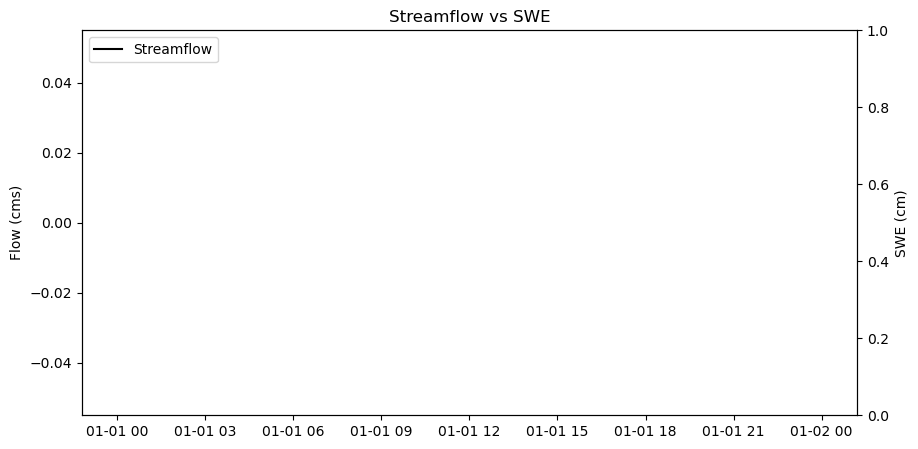

In [36]:
wy = Hydro_df.loc["2019-10-01":"2020-09-30"]

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(wy.index, wy["flow_cms"], label="Streamflow", color="black")
ax1.set_ylabel("Flow (cms)")

ax2 = ax1.twinx()
for col in wy.columns:
    if "SWE" in col:
        ax2.plot(wy.index, wy[col], linestyle="--", label=col)
ax2.set_ylabel("SWE (cm)")

ax1.legend(loc="upper left")
plt.title("Streamflow vs SWE")
plt.show()

### Snowmelt vs Temperature + Radiation

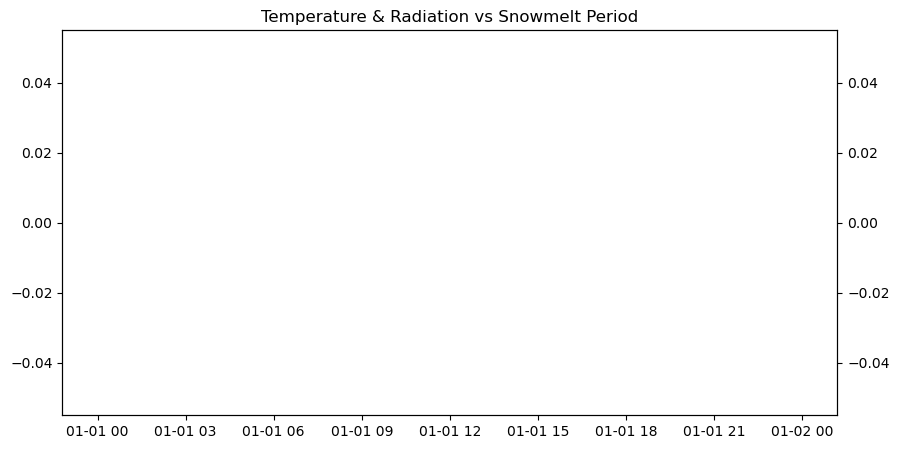

In [37]:
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(wy.index, wy["tmean"], label="Temp", color="red")

ax2 = ax1.twinx()
ax2.plot(wy.index, wy["srad_W_m2"], label="Solar Rad", color="orange")

plt.title("Temperature & Radiation vs Snowmelt Period")
plt.show()

### Rainfall vs Runoff

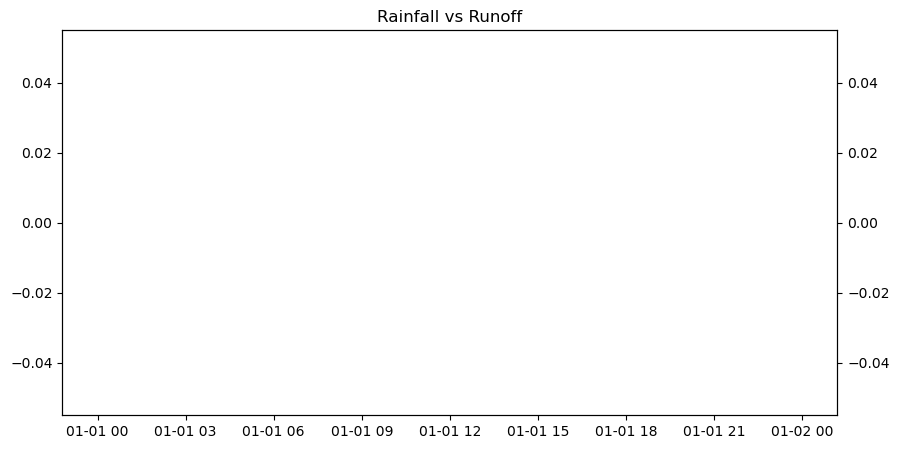

In [38]:
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(wy.index, wy["flow_cms"], label="Streamflow", color="black")

ax2 = ax1.twinx()
ax2.bar(wy.index, wy["prcp_mm_day"], alpha=0.3, label="Precip")

plt.title("Rainfall vs Runoff")
plt.show()

## Data Exploration Exercise #2

Develop a Python script (.py) that you can run in the terminal that collects, processes, and saves your dataframes and a few select figures of interest.